#### Гипотеза 1: Аугментация данных улучшает качество модели.

Импорт необходимых библиотек и загрузка данных baseline моделей.

In [4]:
from common import *
all_results = load_results()

Загрузка сплитов и подготовка параметров

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка сплитов и подготовки параметров
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # список классов
BATCH_SIZE = cfg["batch_size"] # размер батча
IMG_SIZE = cfg["img_size"] # размер изображения
train_indices = cfg["train_indices"] # индексы изображений для тренировочного набора
val_indices = cfg["val_indices"] # индексы изображений для валидационного набора
SEED = cfg["seed"] # seed для воспроизводимости

# настройка датасетов
train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform) # создание датасета для тренировочного набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание датасета для валидационного набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание датасета для тестового набора

# настройка сэмплов в датасете
train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # получение изображений для тренировочного набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # получение изображений для валидационного набора

# настройка загрузчиков данных
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тренировочного набора
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для валидационного набора
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тестового набора

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


Подготовка трансформы для аугментации данных и обновление датасетов и загрузчиков данных.

In [ ]:
# трансформации для аугментации данных
train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # изменение размера изображения
    transforms.RandomHorizontalFlip(), # случайное горизонтальное отражение
    transforms.RandomRotation(15), # случайное вращение
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # случайные изменения яркости, контраста, насыщенности и оттенка
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # случайные аффинные преобразования
    transforms.ToTensor(), # преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]) # нормализация
])

# обновление датасета для аугментации данных
train_dataset_aug = BloodCellsDataset(TRAIN_DIR, transform=train_transform_aug)
train_dataset_aug.samples = [train_dataset_aug.samples[i] for i in train_indices] # получение изображений для тренировочного набора

# обновление загрузчика для аугментации данных
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train loader с аугментацией: {len(train_loader_aug)} batches")

Train loader с аугментацией: 249 batches


Обучение модели ResNet18 с аугментацией данных и оценка её качества на валидационном и тестовом сплитах.

Epoch 1/10 - Train Loss: 0.4425, Train Acc: 0.8222 - Val Loss: 0.5339, Val Acc: 0.8228, Val Bal Acc: 0.8233, Val F1: 0.8090
Epoch 2/10 - Train Loss: 0.2099, Train Acc: 0.9194 - Val Loss: 0.1307, Val Acc: 0.9498, Val Bal Acc: 0.9500, Val F1: 0.9491
Epoch 3/10 - Train Loss: 0.1422, Train Acc: 0.9450 - Val Loss: 0.0773, Val Acc: 0.9714, Val Bal Acc: 0.9715, Val F1: 0.9714
Epoch 4/10 - Train Loss: 0.1105, Train Acc: 0.9567 - Val Loss: 0.0923, Val Acc: 0.9659, Val Bal Acc: 0.9660, Val F1: 0.9659
Epoch 5/10 - Train Loss: 0.0922, Train Acc: 0.9672 - Val Loss: 0.0559, Val Acc: 0.9774, Val Bal Acc: 0.9775, Val F1: 0.9774
Epoch 6/10 - Train Loss: 0.0323, Train Acc: 0.9896 - Val Loss: 0.0115, Val Acc: 0.9970, Val Bal Acc: 0.9970, Val F1: 0.9970
Epoch 7/10 - Train Loss: 0.0216, Train Acc: 0.9944 - Val Loss: 0.0062, Val Acc: 0.9975, Val Bal Acc: 0.9975, Val F1: 0.9975
Epoch 8/10 - Train Loss: 0.0149, Train Acc: 0.9952 - Val Loss: 0.0035, Val Acc: 0.9990, Val Bal Acc: 0.9990, Val F1: 0.9990
Epoch 9/

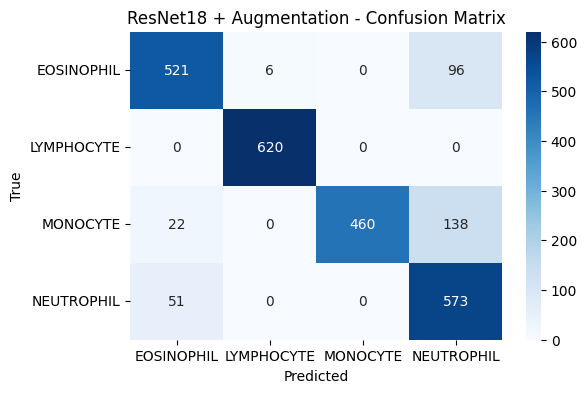

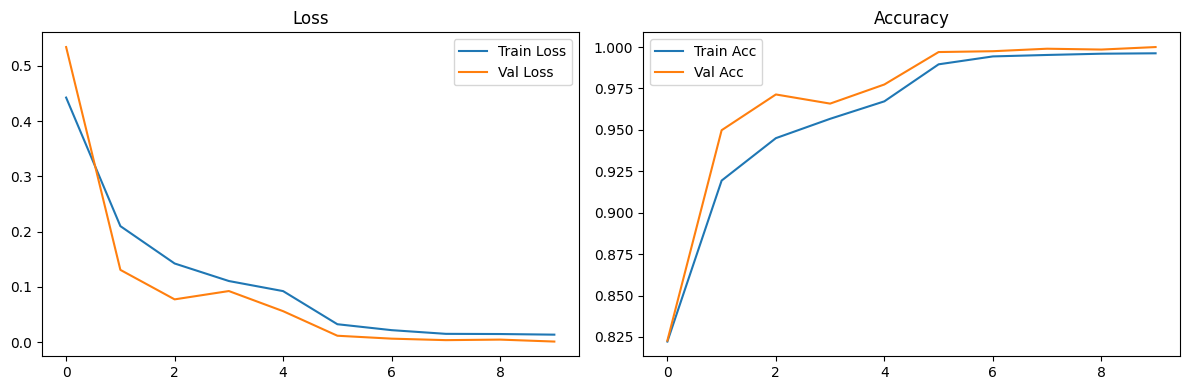


ResNet18 + Augmentation - Classification report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.88      0.84      0.86       623
  LYMPHOCYTE       0.99      1.00      1.00       620
    MONOCYTE       1.00      0.74      0.85       620
  NEUTROPHIL       0.71      0.92      0.80       624

    accuracy                           0.87      2487
   macro avg       0.89      0.87      0.88      2487
weighted avg       0.89      0.87      0.88      2487

Модель сохранена в outputs/resnet18_aug.pth


In [ ]:
resnet18_aug = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # создание модели ResNet18
resnet18_aug.fc = nn.Linear(resnet18_aug.fc.in_features, len(CLASS_NAMES)) # изменение последнего слоя на линейный слой с числом выходов равным числу классов

# обучение модели
resnet18_aug_model, resnet18_aug_result = train_model(
    resnet18_aug,
    "ResNet18 + Augmentation",
    train_loader_aug,
    val_loader,
    test_loader,
    epochs=10,
    lr=1e-3,
)

torch.save(resnet18_aug_model.state_dict(), "outputs/resnet18_aug.pth") # сохранение модели
print("Модель сохранена в outputs/resnet18_aug.pth")

Аугментация (горизонтальный flip, вращение, color jitter и т.п.) дала прирост ~+2% относительно ResNet18 baseline: Accuracy 0.8741 vs 0.8544. Кривые обучения стали более стабильными — аугментация выступила регуляризатором, уменьшив расхождение между тренировочной и валидационной ошибкой. Для ResNet18, обученного с нуля, аугментация особенно важна: она искусственно увеличивает эффективный объём данных, помогая модели не переобучиться на ~7965 тренировочных изображений.

Обучение модели Swin-T с аугментацией данных и оценка её качества на валидационном и тестовом сплитах.

Epoch 1/10 - Train Loss: 0.6143, Train Acc: 0.7386 - Val Loss: 0.1172, Val Acc: 0.9513, Val Bal Acc: 0.9515, Val F1: 0.9514
Epoch 2/10 - Train Loss: 0.1714, Train Acc: 0.9355 - Val Loss: 0.1071, Val Acc: 0.9538, Val Bal Acc: 0.9540, Val F1: 0.9535
Epoch 3/10 - Train Loss: 0.1225, Train Acc: 0.9563 - Val Loss: 0.0344, Val Acc: 0.9900, Val Bal Acc: 0.9900, Val F1: 0.9900
Epoch 4/10 - Train Loss: 0.0795, Train Acc: 0.9724 - Val Loss: 0.0179, Val Acc: 0.9945, Val Bal Acc: 0.9945, Val F1: 0.9945
Epoch 5/10 - Train Loss: 0.0663, Train Acc: 0.9770 - Val Loss: 0.0087, Val Acc: 0.9990, Val Bal Acc: 0.9990, Val F1: 0.9990
Epoch 6/10 - Train Loss: 0.0421, Train Acc: 0.9868 - Val Loss: 0.0060, Val Acc: 0.9995, Val Bal Acc: 0.9995, Val F1: 0.9995
Epoch 7/10 - Train Loss: 0.0396, Train Acc: 0.9866 - Val Loss: 0.0041, Val Acc: 0.9995, Val Bal Acc: 0.9995, Val F1: 0.9995
Epoch 8/10 - Train Loss: 0.0355, Train Acc: 0.9911 - Val Loss: 0.0039, Val Acc: 0.9995, Val Bal Acc: 0.9995, Val F1: 0.9995
Epoch 9/

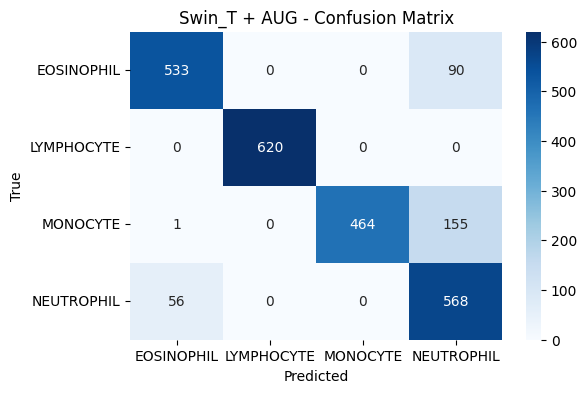

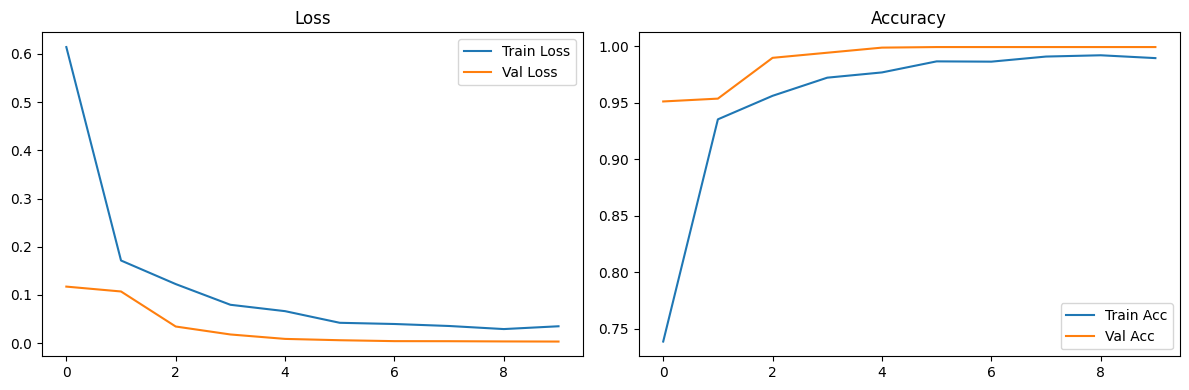


Swin_T + AUG - Classification report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.90      0.86      0.88       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.70      0.91      0.79       624

    accuracy                           0.88      2487
   macro avg       0.90      0.88      0.88      2487
weighted avg       0.90      0.88      0.88      2487



In [ ]:
swin_aug = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1) # создание модели Swin-T
swin_aug.head = nn.Linear(swin_aug.head.in_features, len(CLASS_NAMES)) # изменение последнего слоя на линейный слой с числом выходов равным числу классов

# обучение модели   
swin_aug_model, swin_aug_result = train_model(
    swin_aug, 
    "Swin_T + AUG",
    train_loader_aug, val_loader, test_loader,
    epochs=10,
    lr=2e-5
)

torch.save(swin_aug_model.state_dict(), "outputs/swin_aug.pth") # сохранение модели

Для Swin-T аугментация не принесла улучшений: Accuracy 0.8786 против базового 0.8802 — незначительное ухудшение. Гипотеза для Swin-T не подтвердилась. 

Вероятная причина: предобученные веса Swin-T уже несут богатые инвариантные представления, и агрессивная аугментация на столь малом датасете лишь нарушает распределение входных данных, мешая точной настройке.

Сравнение с baseline моделями и сохранение результатов

In [ ]:
try:
    all_results["resnet18_aug"] = resnet18_aug_result # добавление результатов модели ResNet18 с аугментацией в словарь всех результатов
    all_results["swin_aug"] = swin_aug_result # добавление результатов модели Swin-T с аугментацией в словарь всех результатов
    save_results(all_results) # сохранение всех результатов в файл
except:
    pass

df_aug = pd.DataFrame([all_results["resnet18_aug"], all_results["swin_aug"]]) # создание датафрейма с результатами модели ResNet18 с аугментацией и модели Swin-T с аугментацией
df_compare = pd.concat([
    pd.DataFrame([all_results["baseline_resnet18"], all_results["baseline_swin"]]), # создание датафрейма с результатами baseline моделей
    df_aug # добавление результатов модели ResNet18 с аугментацией и модели Swin-T с аугментацией
], ignore_index=True) # объединение датафреймов

print("Baseline vs Augmentation:")
display(df_compare[["model", "test_acc", "test_bal_acc",  "test_f1_macro"]]) # отображение результатов



Результаты сохранены в outputs/experiment_results.pkl
Baseline vs Augmentation:


,model,test_acc,test_bal_acc,test_f1_macro
0,ResNet18,0.854443,0.854462,0.858832
1,Swin-T,0.880177,0.880147,0.883016
2,ResNet18 + Augmentation,0.874146,0.874120,0.876020
3,Swin_T + AUG,0.878569,0.878545,0.881359


Гипотеза частично подтвердилась — только для ResNet18. Аугментация является эффективным инструментом регуляризации, но её выбор и интенсивность должны соответствовать архитектуре и статусу предобучения модели.